# Notebook 1: Data Pipeline, Data Wrangling, Exploratory Data Analysis




# Libraries

Creating requirements for environment.

In [ ]:
!pip list --format=freeze > requirements.txt

Importing libraries.

In [53]:
from getpass import getpass
import glob
import os
import requests
import urllib

from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import validators

In [54]:
import os
BASE = os.path.abspath('../data')
RAW  = os.path.join(BASE, 'product_metadata')
IMGS = os.path.join(BASE, 'img', 'original')
DATA = os.path.join(BASE, 'processed')

# Reading & Wrangling Data

In [55]:
df = pd.read_csv(f'{RAW}/product_lipstick_metadata.csv')
df.columns

/var/folders/x0/0hqgc7vn3ws2lx6klwmn4fj00000gn/T/ipykernel_16163/1033397575.py:1: DtypeWarning: Columns (8,10,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{RAW}/product_lipstick_metadata.csv')


Index(['category', 'joined', 'brand', 'product', 'shade',
       'shade_description_original', 'shade_description_standardized',
       'skintone_original', 'skintone_standardized', 'undertone_original',
       'undertone_standardized', 'parent_color', 'former_shade',
       'former_description', 'note', 'discontinued', 'launch_year',
       'date_added', 'price', 'product_url1', 'product_url2', 'product_url3',
       'img_url', 'cruelty-free', 'paraben-free', 'vegan', 'gluten-free',
       'clean', 'bipoc-founded', 'oil-free', 'talc-free', 'spf'],
      dtype='object')

## Create Unique ID

We create a stable unique ID before any filtering, so the ID is tied to the source data rather than the filtered subset. This means the ID won't shift between runs if different rows are removed, and it can be used to trace a shade back to the original metadata across notebooks.

The ID is built from `category`, `brand`, `product`, and `shade` — the combination that uniquely identifies a shade in this dataset. Each field is normalised to a clean, consistent format before combining.

In [56]:
import re
import unicodedata

def slugify(text):
    '''
    Converts a string into a clean, consistent format suitable for use in an ID:
    lowercase, accents removed, special characters stripped, spaces replaced with underscores.

    For example:
      "100% Pure"        -> "100_pure"
      "e.l.f. cosmetics" -> "elf_cosmetics"
      "L'Oréal"          -> "loreal"
      "Clé de Peau"      -> "cle_de_peau"
    '''
    if pd.isna(text): return ''
    text = str(text).lower().strip()
    # decompose accented characters (e.g. é -> e + combining accent), then drop the accents
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')
    # remove anything that isn't a letter, number, or space (%, ', &, ., /, etc.)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # collapse whitespace and replace with underscores
    text = re.sub(r'\s+', '_', text.strip())
    return text

df['id'] = (df['category'].apply(slugify) + '__' +
            df['brand'].apply(slugify) + '__' +
            df['product'].apply(slugify) + '__' +
            df['shade'].apply(slugify))

df['id'].head()

0    lipstick__100_pure__fruit_pigmented_cocoa_butt...
1    lipstick__100_pure__fruit_pigmented_cocoa_butt...
2    lipstick__100_pure__fruit_pigmented_cocoa_butt...
3    lipstick__100_pure__fruit_pigmented_cocoa_butt...
4    lipstick__100_pure__fruit_pigmented_cocoa_butt...
Name: id, dtype: object

There is one item that appears twice (`lipstick__mac_cosmetics__frost_lipstick__o`) because they came from different sources so we remove.

In [57]:
df = df.drop_duplicates('id', keep='first')

Although the complete table is +17,000 rows, only 10,679 have images. 

In [58]:
df = df[df.img_url.notna()]
df = df[['id', 'category', 'joined', 'brand', 'product', 'shade', 'img_url', 'shade_description_original']]
df = df.reset_index(drop=True)
df.shape

(10679, 8)

# Collecting Images

## Validate URLs

I validate the URLs in case the data is not an URL. I find that a few cases had something that was not a URL.

In [59]:
df['validation'] = df['img_url'].apply(validators.url)

In [60]:
valid = df['validation'] == True
print(f"Valid URLs:   {valid.sum()}")
print(f"Invalid URLs: {(~valid).sum()}")

Valid URLs:   10643
Invalid URLs: 36


In [61]:
# remove rows with invalid url img 
df = df[df['validation'] == True].reset_index(drop=True)

## Download Images

In [62]:
import time
import random
from tqdm import tqdm

def download(df, dest_folder: str):
  '''
  This function takes the images from the URL and saves them.
  The filename is derived from the unique product ID rather than the URL,
  to avoid collisions when different brands use generic image names like
  'swatch.jpg'. The file extension is still taken from the URL.
  If an URL was broken, the error is saved in img_name for later inspection.
  '''

  df['img_name'] = None
  saved = 0
  failed = 0

  for i in tqdm(range(len(df)), desc='Downloading images'):
    url = df.loc[i, 'img_url']
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/56.0.2924.76 Safari/537.36', "Upgrade-Insecure-Requests": "1","DNT": "1","Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8","Accept-Language": "en-US,en;q=0.5","Accept-Encoding": "gzip, deflate"}

    try:
      r = requests.get(url, headers=headers, timeout=10)

      if r.ok:
        # derive extension from URL, stripping query params first; default to jpg if unclear
        last_segment = url.split('/')[-1].split('?')[0]
        file_type = last_segment.split('.')[-1][0:3] if '.' in last_segment else 'jpg'
        # use the unique product ID as filename to avoid collisions across brands
        file_name = df.loc[i, 'id']
        file_path = dest_folder + '/' + file_name + '.' + file_type

        df.loc[i, 'img_name'] = file_name + '.' + file_type
        with open(file_path, 'wb') as f:
          f.write(r.content)
        saved += 1

      else:  # HTTP status code 4XX/5XX
        df.loc[i, 'img_name'] = r.status_code
        failed += 1

    except requests.exceptions.RequestException as e:
      df.loc[i, 'img_name'] = 'error'
      failed += 1

    # random pause between requests to avoid getting blocked
    time.sleep(random.uniform(0.5, 2.0))

  print(f"Done. Saved: {saved} | Failed: {failed}")
  return df

In [63]:
df = download(df, IMGS)



























































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































Exception igno

Done. Saved: 9502 | Failed: 1141


 Count number of files in directory:

In [64]:
_, _, files = next(os.walk(IMGS))
file_count = len(files)
print('There are: ' + str(file_count) + ' files.')

There are: 9503 files.


# Are all of the files images?

The next step is to check if all of the files are images. I write a function and then, run the function in the folder where all of the files were saved.

In [ ]:
def check_img(filename):
    '''
    Checks whether a file is a valid, uncorrupted image.

    Opens the file twice: once to verify the header and integrity,
    and once to attempt a pixel-level operation (flip), which catches
    files that pass header checks but are truncated or malformed.

    Returns None if the file is valid, or a string describing the error
    if the file is missing, not an image, or corrupted (e.g. an HTML
    response saved as an image file).
    '''
    try:
        im = Image.open(filename)
        im.verify()
        im.close()
        im = Image.open(filename)
        im.transpose(Image.FLIP_LEFT_RIGHT)
        im.close()
        return None  # no error
    except Exception as e:
        return str(e)  # return the reason

Running the function to all of the files, I find that one of the images is corrupted. When trying to open the image, it is a one line of HTML code.

In [71]:
files = pd.Series(glob.glob(f'{IMGS}/*'))
results = pd.DataFrame({'filename': files, 'error': files.apply(check_img)})
corrupted_df = results[results.error.notna()].reset_index(drop=True)

print(f"Corrupted: {len(corrupted_df)} ({len(corrupted_df)/len(results)*100:.1f}%)")
corrupted_df.to_csv(f'{DATA}/corrupted_images.csv', index=False)
corrupted_df

Corrupted: 62 (0.7%)


,filename,error
0,/Users/connie/dev/lipstick_color_extraction/da...,cannot identify image file '/Users/connie/dev/...
1,/Users/connie/dev/lipstick_color_extraction/da...,cannot identify image file '/Users/connie/dev/...
2,/Users/connie/dev/lipstick_color_extraction/da...,image file is truncated (5 bytes not processed)
3,/Users/connie/dev/lipstick_color_extraction/da...,cannot identify image file '/Users/connie/dev/...
4,/Users/connie/dev/lipstick_color_extraction/da...,cannot identify image file '/Users/connie/dev/...
...,...,...
57,/Users/connie/dev/lipstick_color_extraction/da...,cannot identify image file '/Users/connie/dev/...
58,/Users/connie/dev/lipstick_color_extraction/da...,cannot identify image file '/Users/connie/dev/...
59,/Users/connie/dev/lipstick_color_extraction/da...,cannot identify image file '/Users/connie/dev/...
60,/Users/connie/dev/lipstick_color_extraction/da...,cannot identify image file '/Users/connie/dev/...


In [100]:
# flag corrupted images in df so they can be filtered out in later notebooks
corrupted_files = set(corrupted_df['filename'].apply(os.path.basename))
df['img_corrupted'] = df['img_name'].apply(
    lambda x: x in corrupted_files if isinstance(x, str) else False
)

print(f"Flagged as corrupted: {df['img_corrupted'].sum()}")

Flagged as corrupted: 62


# Exploratory Data Analysis

To begin with, I explore brands. The are 418 unique brands and 55.98% of the brands have at least 5 lipsticks in the sample.

In [82]:
brands_count = pd.DataFrame(df['brand'].value_counts())
brands_count = brands_count.reset_index()
brands_count.columns = ['brand', 'total']

n_brands = len(brands_count.brand.unique())
print(f'Percentage of brands with more than 100 lipsticks: {round(len(brands_count[brands_count.total > 100].brand.unique())/n_brands*100, 2)}')
print(f'Percentage of brands with more than 50 lipsticks: {round(len(brands_count[brands_count.total > 50].brand.unique())/n_brands*100, 2)}')
print(f'Percentage of brands with more than 25 lipsticks: {round(len(brands_count[brands_count.total > 25].brand.unique())/n_brands*100, 2)}')
print(f'Percentage of brands with more than 5 lipsticks: {round(len(brands_count[brands_count.total > 5].brand.unique())/n_brands*100, 2)}')

Percentage of brands with more than 100 lipsticks: 6.46
Percentage of brands with more than 50 lipsticks: 12.92
Percentage of brands with more than 25 lipsticks: 23.68
Percentage of brands with more than 5 lipsticks: 55.98


<Axes: xlabel='brand'>

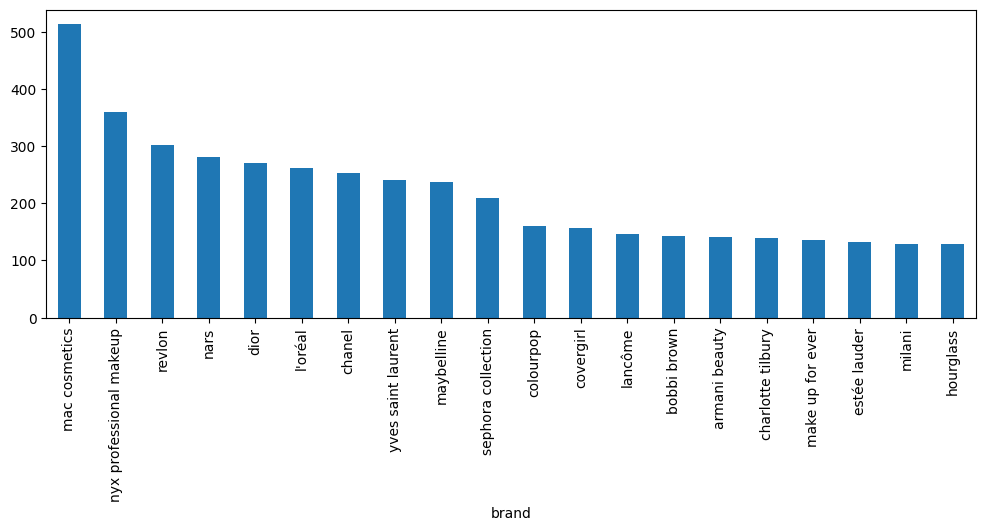

In [79]:
df['brand'].value_counts().head(20).plot.bar(figsize=(12, 4))

# Exploring the Images

To gain deeper insights into our makeup image data, we can extract information on size, resolution, and color distribution from the images in the directory. This analysis offers valuable details about the characteristics of the images and helps us identify patterns within the dataset.



In [83]:
root_path = f'{IMGS}/'

In [85]:
def get_image_size(img_path):
    '''
    Returns the file size in bytes for the given image path.
    '''
    return os.path.getsize(img_path)

def get_resolution(img):
    '''
    Returns the (height, width) in pixels of an image loaded with cv2.
    '''
    return img.shape[:2]

def get_color_distribution(img):
    '''
    Returns a 256-element array counting how many pixels fall on each
    intensity value (0-255) across all channels of the image.
    '''
    return np.bincount(img.flatten(), minlength=256)

In [88]:
df['img_size'] = None
df['img_height'] = None
df['img_width'] = None
df['img_color_distribution'] = None

skipped = 0

for i, row in df.iterrows():
    # skip rows where download failed (None, int error codes, or 'error' string)
    if not isinstance(row['img_name'], str) or row['img_name'] == 'error':
        skipped += 1
        continue

    img_path = os.path.join(IMGS, row['img_name'])
    img = cv2.imread(img_path)

    if img is None:
        skipped += 1
        continue

    df.at[i, 'img_size'] = get_image_size(img_path)
    height, width = get_resolution(img)
    df.at[i, 'img_height'] = height
    df.at[i, 'img_width'] = width
    df.at[i, 'img_color_distribution'] = get_color_distribution(img).tolist()

print(f"Processed: {len(df) - skipped} | Skipped: {skipped}")

Premature end of JPEG file


Processed: 9441 | Skipped: 1202


We can create a histogram that illustrates the distribution of image sizes in our dataset. By plotting the image sizes (in bytes), we can observe the range and frequency of different sizes. This visualization helps us identify outliers and common size patterns, which can be valuable for further analysis. Most of the images are small in bytes.



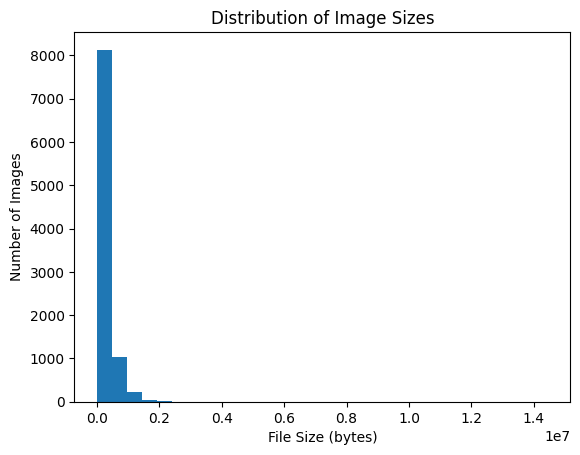

In [91]:
# Plot a histogram of the image sizes
plt.hist(df['img_size'].dropna().astype(float), 30)
plt.title("Distribution of Image Sizes")
plt.xlabel("File Size (bytes)")
plt.ylabel("Number of Images")
plt.show()

Additionally, we can generate a scatter plot that visualizes the distribution of image resolutions (width and height) in our dataset. This plot enables us to detect any relationships, patterns, or clusters among the image dimensions. Analyzing the scatter plot provides insights into the overall size characteristics of the images and helps uncover any irregularities or trends. For instance, one image is considerably larger than all other images in both height and width.

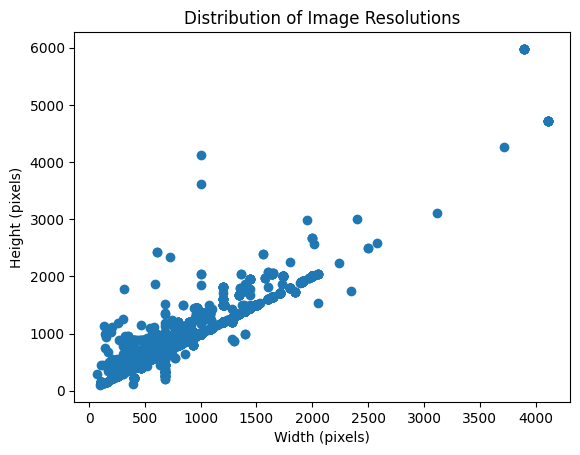

In [92]:
# Plot a scatter plot of the image resolutions
plt.scatter(df['img_width'].dropna().astype(float), df['img_height'].dropna().astype(float))
plt.title("Distribution of Image Resolutions")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()

Analyzing the color distribution of makeup images is a crucial aspect of exploring image data. I'll calculate the mean color distribution across all images to identify the dominant shades within the dataset. This distribution can be visualized with a bar chart, displaying the mean color values and their frequencies, helping us pinpoint the most prominent colors in the makeup image dataset. However, one limitation of this approach is that averaging colors might obscure the nuances of individual shades, potentially blending distinct colors into less representative averages.

In the code below the `np.arange(256)` function generates an array of values from 0 to 255, which corresponds to the possible intensity levels in an 8-bit color channel. This array is used to create a bar chart where each bar represents the frequency of each intensity level, from 0 to 255.

The frequent appearance of 255 could suggest that the dataset contains a lot of very bright regions, possibly because images tend to have a white background.  In an 8-bit RGB image, a white background means that the red, green, and blue channels all have the maximum value of 255. Therefore, if a significant portion of the image consists of a white background, it would result in a high frequency of the 255 intensity value.

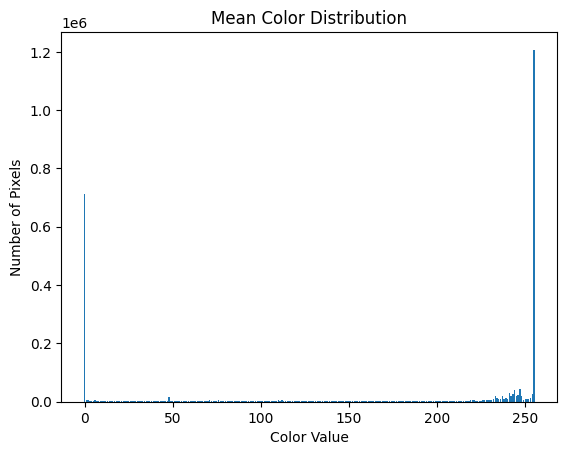

In [94]:
# Calculate the mean color distribution across all images
color_distributions = np.array(df['img_color_distribution'].dropna().tolist())
mean_color_distribution = np.mean(color_distributions, axis=0)

plt.bar(np.arange(256), mean_color_distribution)
plt.title("Mean Color Distribution")
plt.xlabel("Color Value")
plt.ylabel("Number of Pixels")
plt.show()

To gain a deeper understanding of the color properties in individual makeup images, I will use stacked bar charts to visualize the color distributions for each image. This approach allows us to examine the proportion of different colors within each image and detect any distinct patterns or variations. Unlike the mean color distribution method, which averages color values across all images and may obscure individual nuances, stacked bar charts provide a detailed view of the color composition for each image, revealing more specific insights into the dataset.

# Save data

In [101]:
df.to_csv(f'{DATA}/products_with_images.csv')